#Unsupervised Learning: Clustering


## Step 1: EDA & Preprocessing

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000       

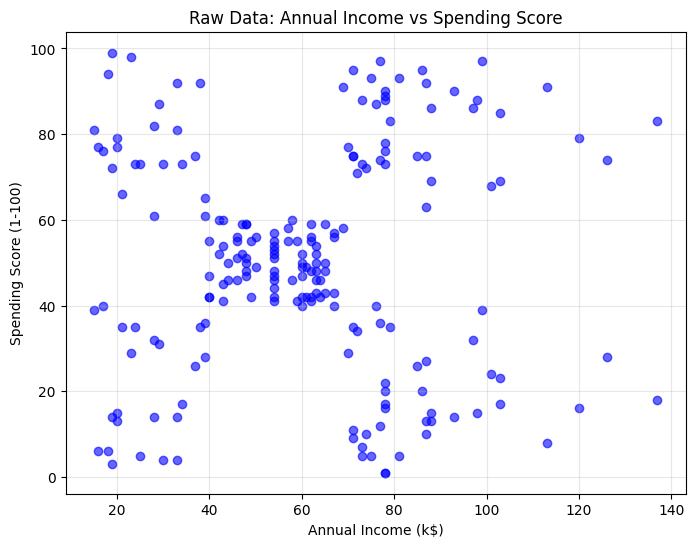

In [6]:
# Downgrade numpy to a compatible version
!pip install numpy==1.26.4 --force-reinstall

# Install missing library
!pip install scikit-learn-extra

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('Mall_Customers.csv')
print(df.head())
print(df.describe())

# Drop CustomerID
df = df.drop('CustomerID', axis=1)

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualize raw data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c='blue', alpha=0.6)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Raw Data: Annual Income vs Spending Score')
plt.grid(True, alpha=0.3)
plt.show()

## Step 2: Find Optimal K (Elbow + Silhouette)

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7ac033907060>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


K=2: Inertia=269.69, Silhouette=0.3213
K=3: Inertia=157.70, Silhouette=0.4666
K=4: Inertia=108.92, Silhouette=0.4939
K=5: Inertia=65.57, Silhouette=0.5547
K=6: Inertia=55.06, Silhouette=0.5399
K=7: Inertia=44.86, Silhouette=0.5281
K=8: Inertia=37.23, Silhouette=0.4552
K=9: Inertia=32.39, Silhouette=0.4571
K=10: Inertia=29.98, Silhouette=0.4432


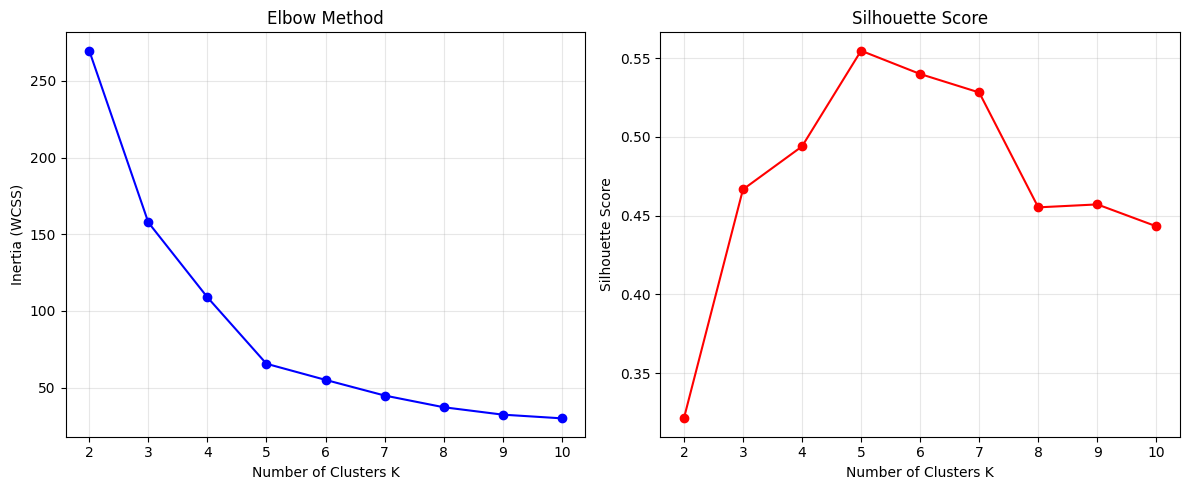

In [2]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'K={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouettes[-1]:.4f}')

# Plot Elbow + Silhouette
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.xlabel('Number of Clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3: Fit K-Means and K-Medoids

In [3]:
chosen_k = 5

# K-Means
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
kmeans_centers = scaler.inverse_transform(kmeans.cluster_centers_)

# K-Medoids
kmedoids = KMedoids(n_clusters=chosen_k, random_state=42, method='pam')
kmedoids_labels = kmedoids.fit_predict(X_scaled)
kmedoids_centers = scaler.inverse_transform(kmedoids.cluster_centers_)

print("K-Means Centroids (Income, Score):")
print(kmeans_centers)
print("\nK-Medoids Medoids (Income, Score):")
print(kmedoids_centers)

K-Means Centroids (Income, Score):
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]

K-Medoids Medoids (Income, Score):
[[88. 15.]
 [79. 83.]
 [28. 14.]
 [20. 79.]
 [54. 51.]]


## Step 4: Side-by-side Visualization

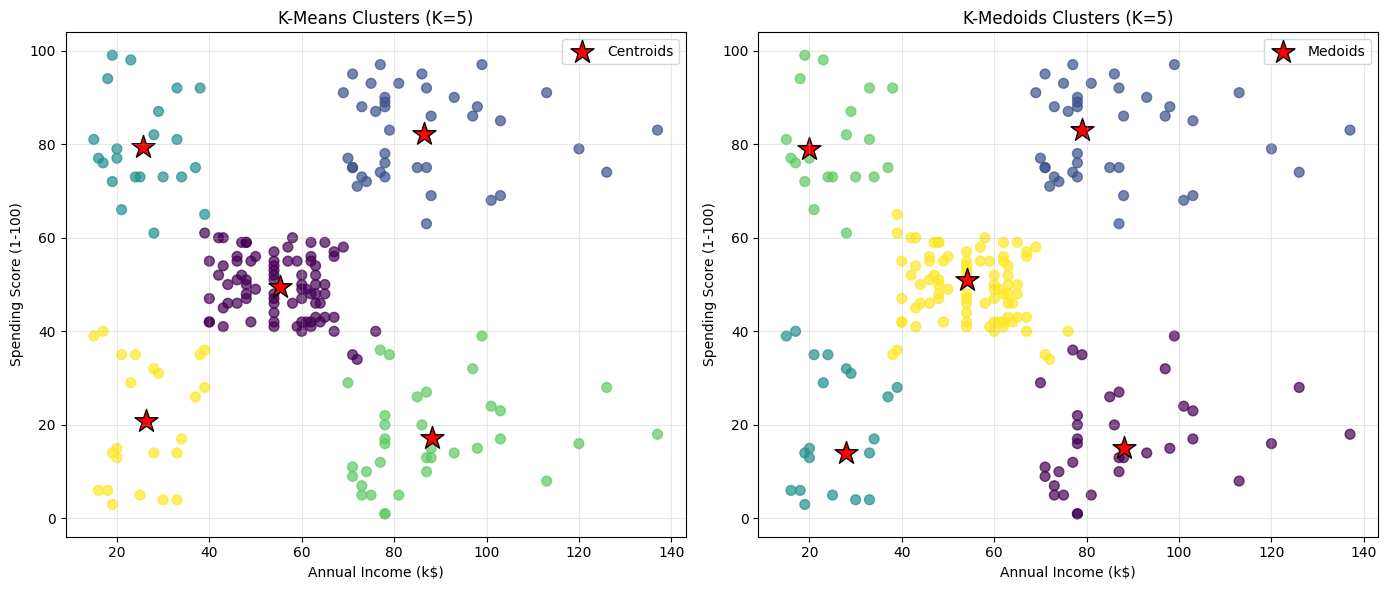

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: K-Means
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7, s=50)
axes[0].scatter(kmeans_centers[:, 0], kmeans_centers[:, 1],
                c='red', marker='*', s=300, edgecolors='black', label='Centroids')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('K-Means Clusters (K=5)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: K-Medoids
axes[1].scatter(X[:, 0], X[:, 1], c=kmedoids_labels, cmap='viridis', alpha=0.7, s=50)
axes[1].scatter(kmedoids_centers[:, 0], kmedoids_centers[:, 1],
                c='red', marker='*', s=300, edgecolors='black', label='Medoids')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].set_title('K-Medoids Clusters (K=5)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5 & 6: Cluster Profiles + Business Insights

In [5]:
# Add cluster labels to original data
df['Cluster'] = kmeans_labels

# Full profile
print(df.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Annual Income (k$)': ['mean', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'min', 'max'],
    'Gender': 'count'
}).round(1))

print("\nAverage values per cluster:")
print(df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1))

print("\nGender distribution:")
print(pd.crosstab(df['Cluster'], df['Gender']))

          Age         Annual Income (k$)          Spending Score (1-100)      \
         mean min max               mean min  max                   mean min   
Cluster                                                                        
0        42.7  18  70               55.3  39   76                   49.5  34   
1        32.7  27  40               86.5  69  137                   82.1  63   
2        25.3  18  35               25.7  15   39                   79.4  61   
3        41.1  19  59               88.2  70  137                   17.1   1   
4        45.2  19  67               26.3  15   39                   20.9   3   

            Gender  
        max  count  
Cluster             
0        61     81  
1        97     39  
2        99     22  
3        39     35  
4        40     23  

Average values per cluster:
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3             

Mall Customer Clustering – Short Report
1. Elbow + Silhouette Analysis
I tested K from 2 to 10 using K-Means.

The Elbow Method shows a clear bend at K = 5. After K=5, the decrease in inertia becomes much smaller.
The Silhouette Score reaches its highest value at K = 5 (0.5547).

Chosen K = 5
Justification: Both the elbow and the silhouette score agree that 5 is the optimal number of clusters. It gives the best balance between compactness and separation of clusters.

2. Cluster Visualization
Side-by-side scatter plots were created:

Left plot: K-Means clusters with red stars showing the centroids
Right plot: K-Medoids clusters with red stars showing the medoids

Both algorithms produced very similar groupings of customers.

3. Algorithm Comparison
Why medoids lie on real points while centroids can float:

K-Means calculates the centroid (the average/mean) of all points in a cluster. This average can fall in an empty area of the graph (it does not have to be an actual customer).
K-Medoids selects a real data point as the center (called a medoid). Therefore, the center always lies on an actual customer.

Which handles outliers better?
K-Medoids handles outliers better. Because the center must be a real point, one extreme outlier cannot pull the center far away. In K-Means, a single outlier can strongly shift the centroid.

4. Business Insight – Highest-Spending Customer Profile
The highest-spending customers belong mainly to two groups:

Cluster 1 (highest spenders):
Average age ≈ 33 years (mostly 27–40),
High annual income (≈ 86–87 k$),
Very high spending score (≈ 82).
Cluster 2 (second highest):
Younger customers (average age ≈ 25),
Lower income, but still high spending score (≈ 79).

Summary of highest-spending profile:
Young to early middle-aged customers (especially 25–40 years old) with either high income or strong spending behavior.

5. Business Insights and Interpretation (Actionable Strategies)



































ClusterCustomer ProfileRecommended Strategy1High Income + High Spending (Age ~33)VIP treatment, exclusive offers, premium products2Low Income + High Spending (Young, Age ~25)Trend products, social media marketing, installment plans3High Income + Low SpendingQuality & value messaging to increase their spending0Average Income + Average SpendingSeasonal promotions and cross-selling4Low Income + Low SpendingBudget-friendly products and basic promotions
Key Recommendations:

Focus marketing budget on Cluster 1 (most profitable).
Convert Cluster 3 (high income but careful spenders) into higher spenders with better value communication.
Use social media and trendy campaigns for the young high-spenders in Cluster 2.